# Tile test: accuracy and classification time

Line plots for **concentric circles** and **plant tissue** from `test-results/tile-tests/`. The example cell overlays **IBM Marrakesh** (solid lines, round markers) and **Fake Marrakesh** (dashed lines, square markers) on the same axes.

Thanks CursorAI

In [ ]:
from __future__ import annotations

from pathlib import Path
import subprocess
import sys

try:
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Load CSVs from repo root whether the kernel cwd is the project root or exploration_notebooks/
def _figures_output_dir() -> Path:
    """Use the thesis repo's ``figures/`` (same directory that holds ``exploration_notebooks/``)."""
    cwd = Path.cwd().resolve()
    if cwd.name == "exploration_notebooks":
        out = cwd.parent / "figures"
    else:
        out = cwd / "figures"
    out.mkdir(parents=True, exist_ok=True)
    return out.resolve()


cwd = Path.cwd().resolve()
plot_dir = _figures_output_dir()

def _load_tile_test_csv(filename: str) -> pd.DataFrame:
    cwd = Path.cwd().resolve()
    for root in (cwd, cwd.parent):
        path = root / filename
        if path.is_file():
            return pd.read_csv(path)
    raise FileNotFoundError(
        f"Could not find {filename} under {cwd} or {cwd.parent}. "
        "Open the notebook from the repo or set the kernel cwd to exploration_notebooks/."
    )


def _tile_edge_and_sorted(df: pd.DataFrame, ycol: str) -> tuple[list[int], list[float]]:
    tmp = df.copy()
    tmp["_edge"] = tmp["tile_size"].astype(str).str.split("x").str[0].astype(int)
    tmp = tmp.sort_values("_edge")
    return tmp["_edge"].tolist(), tmp[ycol].astype(float).tolist()


def plot_mean_accuracy(
    circle_df: pd.DataFrame,
    plant_df: pd.DataFrame,
    *,
    label_circle: str = "Synthetic dataset",
    label_plant: str = "Plant dataset",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Mean accuracy vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of mean accuracy for both test images on one axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((circle_df, plant_df), (label_circle, label_plant), colors):
        x, y = _tile_edge_and_sorted(df, "mean_accuracy")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    ax.set_xticks(sorted(set(_tile_edge_and_sorted(circle_df, "mean_accuracy")[0])))
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_s(
    circle_df: pd.DataFrame,
    plant_df: pd.DataFrame,
    *,
    label_circle: str = "Synthetic dataset",
    label_plant: str = "Plant dataset",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Average Classification Time vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of avg_classification_s for both test images on one axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((circle_df, plant_df), (label_circle, label_plant), colors):
        x, y = _tile_edge_and_sorted(df, "avg_classification_s")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    ax.set_xticks(sorted(set(_tile_edge_and_sorted(circle_df, "avg_classification_s")[0])))
    fig.tight_layout()
    return fig, ax


def _unpack_tile_overlay_row(
    row: tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str],
) -> tuple[pd.DataFrame, str, str, str, str]:
    """(df, label, color, linestyle) or add optional ``marker`` (``o`` = hardware, ``s`` = fake).

    If marker is omitted: solid ``-`` → round ``o``; any other linestyle → square ``s``.
    """
    if len(row) == 5:
        df, lab, color, ls, mk = row
        return df, lab, color, ls, mk
    df, lab, color, ls = row
    mk = "o" if ls.strip() == "-" else "s"
    return df, lab, color, ls, mk


def plot_mean_accuracy_multi(
    series: list[
        tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str]
    ],
    *,
    ax: plt.Axes | None = None,
    title: str | None = "Mean accuracy vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Multiple overlays; each row is (df, label, color, linestyle) or (... , marker)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.figure
    all_edges: set[int] = set()
    for row in series:
        df, lab, color, ls, mk = _unpack_tile_overlay_row(row)
        x, y = _tile_edge_and_sorted(df, "mean_accuracy")
        all_edges.update(x)
        ax.plot(
            x,
            y,
            marker=mk,
            markersize=8,
            linewidth=2,
            label=lab,
            color=color,
            linestyle=ls,
        )
    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    ax.set_xticks(sorted(all_edges))
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_s_multi(
    series: list[
        tuple[pd.DataFrame, str, str, str] | tuple[pd.DataFrame, str, str, str, str]
    ],
    *,
    ax: plt.Axes | None = None,
    title: str | None = "Average Classification Time vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Same rows as ``plot_mean_accuracy_multi`` (optional per-series marker)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.figure
    all_edges: set[int] = set()
    for row in series:
        df, lab, color, ls, mk = _unpack_tile_overlay_row(row)
        x, y = _tile_edge_and_sorted(df, "avg_classification_s")
        all_edges.update(x)
        ax.plot(
            x,
            y,
            marker=mk,
            markersize=8,
            linewidth=2,
            label=lab,
            color=color,
            linestyle=ls,
        )
    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    ax.set_xticks(sorted(all_edges))
    fig.tight_layout()
    return fig, ax


def _shot_scale_sorted(df: pd.DataFrame, ycol: str) -> tuple[list[float], list[float]]:
    """Sort by ``shot_scale_2_pow_k`` (2**k) for line plots vs shot budget."""
    tmp = df.copy()
    tmp = tmp.sort_values("shot_scale_2_pow_k")
    return (
        tmp["shot_scale_2_pow_k"].astype(float).tolist(),
        tmp[ycol].astype(float).tolist(),
    )


def plot_mean_accuracy_vs_shot_scale(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    *,
    label_a: str = "c-mode A",
    label_b: str = "c-mode B",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Mean accuracy vs shot scale",
    xlog: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of mean accuracy vs ``shot_scale_2_pow_k`` for two CSV result sets."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((df_a, df_b), (label_a, label_b), colors):
        x, y = _shot_scale_sorted(df, "mean_accuracy")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Number of Shots per Data Point")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    if xlog:
        ax.set_xscale("log")
        ax.set_xticks(sorted(set(_shot_scale_sorted(df_a, "mean_accuracy")[0])))
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_vs_shot_scale(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    *,
    label_a: str = "c-mode A",
    label_b: str = "c-mode B",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Average classification time vs shot scale",
    xlog: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of avg_classification_s vs ``shot_scale_2_pow_k`` for two CSV result sets."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((df_a, df_b), (label_a, label_b), colors):
        x, y = _shot_scale_sorted(df, "avg_classification_s")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Number of Shots per Data Point")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    if xlog:
        ax.set_xscale("log")
        ax.set_xticks(sorted(set(_shot_scale_sorted(df_a, "avg_classification_s")[0])))
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    fig.tight_layout()
    return fig, ax

In [ ]:
# Example: IBM Marrakesh + Fake Marrakesh on the same axes (solid = hardware, dashed = simulator).
# Markers: round (o) for hardware, square (s) for fake — applied automatically from linestyle, or pass a 5th tuple element.
COLORS = ("#1f77b4", "#ff7f0e")

circle_ibm = _load_tile_test_csv("../test-results/tile-tests/ibm-marrakesh/circle_marrakesh_hw_sc12_results.csv")
plant_ibm = _load_tile_test_csv("../test-results/tile-tests/ibm-marrakesh/plant_marrakesh_hw_sc12_results.csv")
circle_fake = _load_tile_test_csv(
    "../test-results/tile-tests/fake-marrakesh/circle_16x16_method_1_iso_0_marrakesh_sc12_results.csv"
)
plant_fake = _load_tile_test_csv(
    "../test-results/tile-tests/fake-marrakesh/plant_2_16x16_method_1_iso_0_marrakesh_sc12_results.csv"
)

_acc_series = [
    (circle_ibm, "Synthetic (IBM Marrakesh)", COLORS[0], "-"),
    (plant_ibm, "Plant (IBM Marrakesh)", COLORS[1], "-"),
    (circle_fake, "Synthetic (Fake Marrakesh)", COLORS[0], "--"),
    (plant_fake, "Plant (Fake Marrakesh)", COLORS[1], "--"),
]

fig_acc, _ = plot_mean_accuracy_multi(_acc_series, title=None)
acc_path = plot_dir / "tile_test_mean_accuracy.png"
fig_acc.savefig(acc_path, dpi=300, bbox_inches="tight")
print(f"Saved: {acc_path.resolve()}")
plt.show()

fig_time, _ = plot_avg_classification_s_multi(_acc_series, title=None)
time_path = plot_dir / "tile_test_avg_classification_s.png"
fig_time.savefig(time_path, dpi=300, bbox_inches="tight")
print(f"Saved: {time_path.resolve()}")
plt.show()



In [ ]:
# 64x64 iso-0.5 shot-scale sweeps: synthetic (circle) + plant on shared axes (-n vs -t CSVs)
circle_iso_n_df = _load_tile_test_csv("../circle_64x64_method_1_iso-0.5-n_results.csv")
circle_iso_t_df = _load_tile_test_csv("../circle_64x64_method_1_iso-0.5-t_results.csv")
plant_iso_n_df = _load_tile_test_csv("../plant_2_64x64_method_1_iso-0.5-n_results.csv")
plant_iso_t_df = _load_tile_test_csv("../plant_2_64x64_method_1_iso-0.5-t_results.csv")

SHOT_LABEL_A = "Baseline method"
SHOT_LABEL_B = "Isovalue-Weight Encoding"

# Synthetic = blue pair; plant = orange pair (darker = baseline -n, lighter = isovalue -t)
_shot_series = (
    (circle_iso_n_df, f"Synthetic: {SHOT_LABEL_A}", "#2171b5"),
    (circle_iso_t_df, f"Synthetic: {SHOT_LABEL_B}", "#9ecae1"),
    (plant_iso_n_df, f"Plant: {SHOT_LABEL_A}", "#d94801"),
    (plant_iso_t_df, f"Plant: {SHOT_LABEL_B}", "#fd8d3c"),
)

_x_all = sorted(
    set()
    .union(*(_shot_scale_sorted(df, "mean_accuracy")[0] for df, _, _ in _shot_series))
    .union(*(_shot_scale_sorted(df, "avg_classification_s")[0] for df, _, _ in _shot_series))
)

fig_acc, ax_acc = plt.subplots(figsize=(9, 5))
for df, lab, color in _shot_series:
    x, y = _shot_scale_sorted(df, "mean_accuracy")
    ax_acc.plot(x, y, marker="o", linewidth=2, label=lab, color=color)
ax_acc.set_xlabel("Number of Shots per Data Point")
ax_acc.set_ylabel("Mean accuracy")
ax_acc.legend()
ax_acc.grid(True, alpha=0.35)
ax_acc.set_xscale("log")
ax_acc.set_xticks(_x_all)
ax_acc.get_xaxis().set_major_formatter(ScalarFormatter())
fig_acc.tight_layout()

combined_shot_acc_path = plot_dir / "combined_64x64_iso-0.5_shot_scale_mean_accuracy.png"
fig_acc.savefig(combined_shot_acc_path, dpi=300, bbox_inches="tight")
print(f"Saved: {combined_shot_acc_path.resolve()}")
plt.show()

fig_time, ax_time = plt.subplots(figsize=(9, 5))
for df, lab, color in _shot_series:
    x, y = _shot_scale_sorted(df, "avg_classification_s")
    ax_time.plot(x, y, marker="o", linewidth=2, label=lab, color=color)
ax_time.set_xlabel("Number of Shots per Data Point")
ax_time.set_ylabel("Average classification time (s)")
ax_time.legend()
ax_time.grid(True, alpha=0.35)
ax_time.set_xscale("log")
ax_time.set_xticks(_x_all)
ax_time.get_xaxis().set_major_formatter(ScalarFormatter())
fig_time.tight_layout()

combined_shot_time_path = plot_dir / "combined_64x64_iso-0.5_shot_scale_avg_classification_s.png"
fig_time.savefig(combined_shot_time_path, dpi=300, bbox_inches="tight")
print(f"Saved: {combined_shot_time_path.resolve()}")
plt.show()


Saved: C:\Users\burne\Documents\SchoolWork\QC-Classes\Coding Projects\Marching-Qubes-Thesis\figures\tile_test_depth_vs_mean_accuracy.png


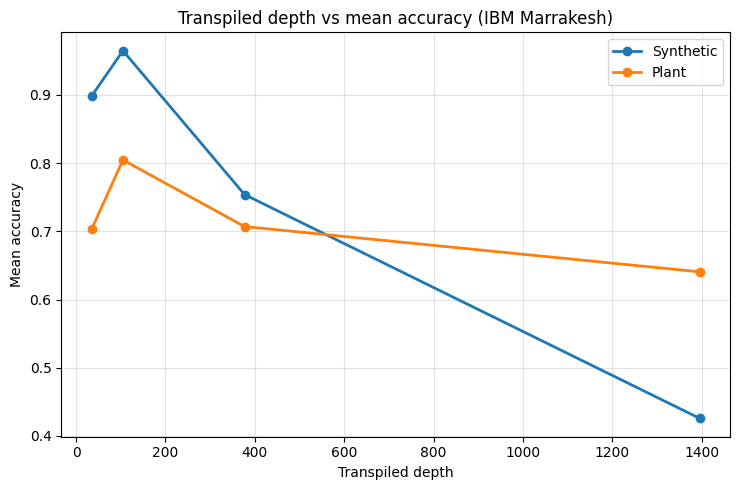

In [16]:
# Depth vs accuracy (transpiled depth from JobOutputs JSON, mean accuracy from tile-test CSV)
# Assumes 16x16 images => n_tiles = (16 / tile_edge)^2
import json

JOB_INFO_PATH = "../JobOutputs/job_submission_info.json"

job_info = json.loads(Path(JOB_INFO_PATH).read_text(encoding="utf-8"))


def _expected_n_tiles(tile_edge: int, full_edge: int = 16) -> int:
    if full_edge % tile_edge != 0:
        raise ValueError(f"full_edge={full_edge} not divisible by tile_edge={tile_edge}")
    return (full_edge // tile_edge) ** 2


def _depth_for_tile_edge(tile_edge: int) -> int:
    want_n_tiles = _expected_n_tiles(tile_edge)

    # Prefer the aggregated tile-test jobs (these include n_tiles)
    for rec in job_info.values():
        if rec.get("tile_width") == tile_edge and rec.get("tile_height") == tile_edge and rec.get("n_tiles") == want_n_tiles:
            return int(rec["transpiled_depth"])

    # Fallback: any matching tile size
    for rec in job_info.values():
        if rec.get("tile_width") == tile_edge and rec.get("tile_height") == tile_edge:
            return int(rec["transpiled_depth"])

    raise KeyError(f"No job found for tile_edge={tile_edge}")


def _depth_vs_accuracy_points(df: pd.DataFrame) -> tuple[list[int], list[float]]:
    edges, acc = _tile_edge_and_sorted(df, "mean_accuracy")
    depths = [_depth_for_tile_edge(e) for e in edges]
    return depths, acc


# Use the already-loaded circle_ibm / plant_ibm if present (from earlier cells); otherwise load them.
try:
    circle_df_for_depth = circle_ibm
    plant_df_for_depth = plant_ibm
except NameError:
    circle_df_for_depth = _load_tile_test_csv("../test-results/tile-tests/ibm-marrakesh/circle_marrakesh_hw_sc12_results.csv")
    plant_df_for_depth = _load_tile_test_csv("../test-results/tile-tests/ibm-marrakesh/plant_marrakesh_hw_sc12_results.csv")

x_circle, y_circle = _depth_vs_accuracy_points(circle_df_for_depth)
x_plant, y_plant = _depth_vs_accuracy_points(plant_df_for_depth)

# Sort by depth so the lines connect left-to-right
circle_pairs = sorted(zip(x_circle, y_circle))
plant_pairs = sorted(zip(x_plant, y_plant))
x_circle_s, y_circle_s = (list(t) for t in zip(*circle_pairs))
x_plant_s, y_plant_s = (list(t) for t in zip(*plant_pairs))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(x_circle_s, y_circle_s, label="Synthetic", color="#1f77b4", marker="o", linewidth=2)
ax.plot(x_plant_s, y_plant_s, label="Plant", color="#ff7f0e", marker="o", linewidth=2)

ax.set_xlabel("Transpiled depth")
ax.set_ylabel("Mean accuracy")
ax.set_title("Transpiled depth vs mean accuracy (IBM Marrakesh)")
ax.grid(True, alpha=0.35)
ax.legend()
fig.tight_layout()

out_path = plot_dir / "tile_test_depth_vs_mean_accuracy.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path.resolve()}")
plt.show()
